In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
# load the dataset
df = pd.read_csv("ECommerce_Sales_Forecasting_Dataset.csv")
print("Dataset loaded successfully")
print(df.head())

Dataset loaded successfully
         Date      Branch   Region  Promotion  Holiday  Season  Weekday  \
0  2024-01-01     Chennai    North          0        1  Winter        0   
1  2024-01-01     Madurai    South          0        1  Winter        0   
2  2024-01-01  Coimbatore     West          0        1  Winter        0   
3  2024-01-01      Trichy  Central          0        1  Winter        0   
4  2024-01-01       Salem     West          0        1  Winter        0   

   Weekend  Sales  
0        0  29402  
1        0  23303  
2        0  26871  
3        0  22533  
4        0  23028  


In [14]:
# check basic info
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       1825 non-null   object
 1   Branch     1825 non-null   object
 2   Region     1825 non-null   object
 3   Promotion  1825 non-null   int64 
 4   Holiday    1825 non-null   int64 
 5   Season     1825 non-null   object
 6   Weekday    1825 non-null   int64 
 7   Weekend    1825 non-null   int64 
 8   Sales      1825 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 128.4+ KB


In [15]:
# find the date column
date_col = None
for col in df.columns:
    if "date" in col.lower():
        date_col = col
        break

if date_col is None:
    raise ValueError("No date column found in the dataset")

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

# simple date features
df["Day"] = df[date_col].dt.day
df["Month"] = df[date_col].dt.month
df["Year"] = df[date_col].dt.year
df["Weekday"] = df[date_col].dt.weekday

print("Date column:", date_col)
print(df[[date_col, "Day", "Month", "Year", "Weekday"]].head())

Date column: Date
        Date  Day  Month  Year  Weekday
0 2024-01-01    1      1  2024        0
1 2024-01-01    1      1  2024        0
2 2024-01-01    1      1  2024        0
3 2024-01-01    1      1  2024        0
4 2024-01-01    1      1  2024        0


In [16]:
# find the sales column
target_col = None
for col in df.columns:
    if "sales" in col.lower():
        target_col = col
        break

if target_col is None:
    raise ValueError("No sales column found in the dataset")

print("Target column:", target_col)

# using only simple date features for the model
feature_columns = ["Day", "Month", "Year", "Weekday"]

X = df[feature_columns].copy()
y = df[target_col].copy()

X = X.fillna(0)
y = y.fillna(y.mean())

print("Features used:", feature_columns)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Target column: Sales
Features used: ['Day', 'Month', 'Year', 'Weekday']
Shape of X: (1825, 4)
Shape of y: (1825,)


In [17]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1460, 4)
Testing set shape: (365, 4)


In [18]:
# train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [19]:
# make predictions
y_pred = model.predict(X_test)

print("First 5 actual values:", y_test.values[:5])
print("First 5 predicted values:", np.round(y_pred[:5], 2))

First 5 actual values: [26960 18771 22217 19740 24401]
First 5 predicted values: [22723.04 21957.88 22206.   22632.71 21311.26]


In [20]:
# evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 4))

MAE : 3085.67
MSE : 13423841.94
RMSE: 3663.86
R2  : -0.0039


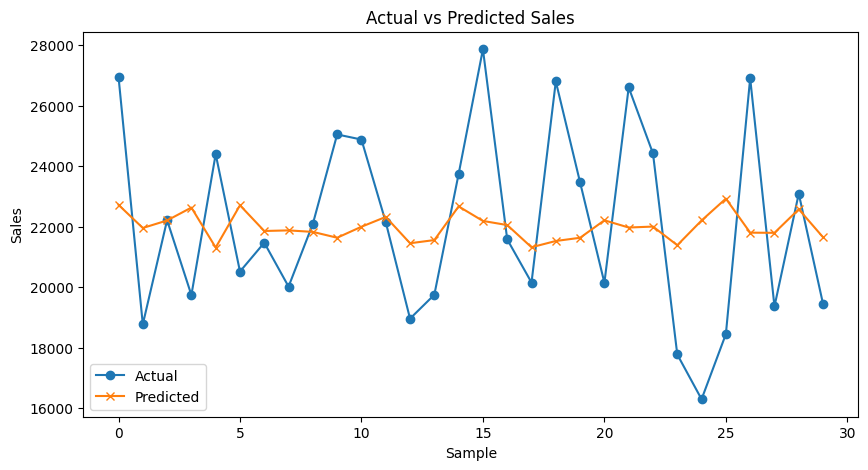

In [21]:
# plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:30], marker="o", label="Actual")
plt.plot(y_pred[:30], marker="x", label="Predicted")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Sample")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [22]:
# simple future prediction example
future_data = pd.DataFrame({
    "Day": [15],
    "Month": [8],
    "Year": [2025],
    "Weekday": [4]
})

future_sales = model.predict(future_data)
print("Future input:")
print(future_data)
print("Predicted future sales:", round(future_sales[0], 2))

Future input:
   Day  Month  Year  Weekday
0   15      8  2025        4
Predicted future sales: 22032.85
